In [41]:
import torch
import torch.nn as nn
import math
from torch.utils.data import TensorDataset, DataLoader
import re
import unicodedata
import os

checkpoint_path = "transformer_amen_v1.pth"

PAD_TOKEN = 0
SOS_TOKEN = 1
EOS_TOKEN = 2
MAX_LENGTH = 40

# Vocabulary & Data Pipeline Refactoring

In [42]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.word2count = {}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word2count[word] = 1
            self.n_words += 1
        else:
            self.word2count[word] += 1

# Helper functions for text normalization

def unicode_to_ascii(s):
    for c in unicodedata.normalize('NFD', s):
        if unicodedata.category(c) != 'Mn':
            yield c

def normalize_english(s):
    """Normalization for the English (target) side: lowercase, strip accents,
    keep only Latin letters and sentence punctuation."""
    s = ''.join(unicode_to_ascii(s.lower().strip()))
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

# Amharic (Ge'ez script) has no case and no Latin-style accents, so the old
# "strip accents + keep a-zA-Z" pipeline would erase every Amharic character.
# Instead we keep the Ethiopic Unicode block and its native punctuation, and
# space out punctuation marks the same way the English pipeline does.
ETHIOPIC_RANGE = r"\u1200-\u137F\u1380-\u139F\u2D80-\u2DDF"
ETHIOPIC_PUNCT = "።፤፣፦፧፨"

def normalize_amharic(s):
    """Normalization for the Amharic (source) side: keep Ethiopic script and
    its native punctuation, drop anything else (Latin stragglers, digits, etc.)."""
    s = str(s).strip()
    # Space out Amharic punctuation so it tokenizes as its own "word", mirroring
    # how normalize_english spaces out . ! ?
    s = re.sub(r"([" + ETHIOPIC_PUNCT + r"])", r" \1 ", s)
    s = re.sub(r"[^" + ETHIOPIC_RANGE + ETHIOPIC_PUNCT + r"\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def sentence_to_indices(lang, sentence):
    indicies = []
    for word in sentence.split(' '):
        token_id = lang.word2index.get(word, 3)
        indicies.append(token_id)
    indicies.append(EOS_TOKEN)  # EOS at end
    return indicies

def pad_sequence(indicies, max_length):
    if len(indicies) < max_length:
        return indicies + [PAD_TOKEN] * (max_length - len(indicies))
    return indicies[:max_length-1] + [EOS_TOKEN]

def prepare_data_loader(pairs, input_lang, output_lang, batch_size=32):
    input_tensors = []
    target_tensors = []

    for pair in pairs:
        input_idx = pad_sequence(sentence_to_indices(input_lang, pair[0]), MAX_LENGTH)

        # FIX: We MUST prepend the <SOS> token so the Decoder learns what to generate first!
        raw_target_indices = sentence_to_indices(output_lang, pair[1])
        target_idx = pad_sequence([SOS_TOKEN] + raw_target_indices, MAX_LENGTH)

        input_tensors.append(input_idx)
        target_tensors.append(target_idx)

    # Wrap data into TensorDataset and DataLoader
    dataset = TensorDataset(torch.tensor(input_tensors, dtype=torch.long),
                            torch.tensor(target_tensors, dtype=torch.long))

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return loader

# PE, MHA, FF

In [43]:
class PE(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [Batch, Seq_length, d_model]
        return x + self.pe[:, :x.size(1)]

In [44]:
class MHA(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model %n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)

    def forward(self, q,k,v, mask=None):
        B, S, _ = q.shape
        _, S_k , _ = k.shape

        # B S H D_k -> B H S D_k
        Q = self.q_linear(q).view(B, S, self.n_heads, self.d_k).transpose(1,2)
        K = self.k_linear(k).view(B, S_k, self.n_heads, self.d_k).transpose(1,2)
        V = self.v_linear(v).view(B, S_k, self.n_heads, self.d_k).transpose(1,2)

        # Scaled dot-product calculation: (Q @ K.T) / sqrt(d_k) [cite: 31]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attention_weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)

        # Concatenate heads and pass through final linear layer
        context = context.transpose(1,2).contiguous().view(B, S, self.d_model)
        output = self.out_linear(context)

        # Average for a 2D cross attention matrix
        mean_attention = attention_weights.mean(dim=1)

        return output, mean_attention



In [45]:
import torch.nn.functional as F

class FF(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))

# Transformer Encoder Layer Structure

```text
  [Input Tensor: x] (Shape: [B, S, d_model])
         │
     ┌───├───┐ (Save for Residual 1)
     ▼   ▼   ▼
   ┌───────────┐
   │    MHA    │  ◄── Self-Attention: q=x, k=x, v=x
   └─────┬─────┘
         ▼
         + <───┘ (Residual Addition: x + Dropout(MHA_out))
         ▼
   ┌───────────┐
   │ LayerNorm │  ◄── norm1
   └─────┬─────┘
         ▼
  [Intermediate State: x_norm1]
         │
         ├───┐ (Save for Residual 2)
         ▼   ▼
   ┌───────────┐
   │    FFN    │  ◄── Position-wise Feed-Forward Network
   └─────┬─────┘
         ▼
         + <───┘ (Residual Addition: x_norm1 + Dropout(FFN_out))
         ▼
   ┌───────────┐
   │ LayerNorm │  ◄── norm2
   └─────┬─────┘
         ▼
  [Output Tensor] (Shape: [B, S, d_model])

In [46]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MHA(d_model, n_heads)
        self.ffn = FF(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self,x,mask=None):
        attn_out, _ = self.mha(q=x,k=x,v=x,mask=mask)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))

        return x

# Transformer Decoder Layer Structure

```text
       [Input Target Tensor: x] (Shape: [B, S, d_model])
                  │
                  ├───┐ (Save for Residual 1)
                  ▼   ▼
            ┌───────────┐
            │Masked MHA │  ◄── Target Self-Attention (Causal Mask)
            └─────┬─────┘      q=x, k=x, v=x
                  ▼
                  + <───┘ (Residual Addition: x + Dropout(Masked_MHA_out))
                  ▼
            ┌───────────┐
            │ LayerNorm │  ◄── norm1
            └─────┬─────┘
                  ▼
         [State: x_norm1]
                  │
                  ├───┐ (Save for Residual 2)
                  ▼   ▼
            ┌───────────┐
            │ Cross-MHA │  ◄── Cross-Attention: q = x_norm1
            └─────┬─────┘                       k, v = Encoder Output
                  ▼                             (Shape: [B, S, d_model])
                  + <───┘ (Residual Addition: x_norm1 + Dropout(Cross_MHA_out))
                  ▼
            ┌───────────┐
            │ LayerNorm │  ◄── norm2
            └─────┬─────┘
                  ▼
         [State: x_norm2]
                  │
                  ├───┐ (Save for Residual 3)
                  ▼   ▼
            ┌───────────┐
            │    FFN    │  ◄── Position-wise Feed-Forward Network
            └─────┬─────┘
                  ▼
                  + <───┘ (Residual Addition: x_norm2 + Dropout(FFN_out))
                  ▼
            ┌───────────┐
            │ LayerNorm │  ◄── norm3
            └─────┬─────┘
                  ▼
    [Output Tensor] (Shape: [B, T, d_model])

In [47]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.masked_mha = MHA(d_model, n_heads)
        self.cross_mha = MHA(d_model, n_heads)
        self.ffn = FF(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # 1. Masked Self-Attention (Target attending to Target)
        attn_out1, _ = self.masked_mha(q=x, k=x, v=x, mask=tgt_mask)
        x = self.norm1(x + self.dropout(attn_out1))

        # 2. Cross-Attention (Decoder Q connects to Encoder K, V)
        # We save and return cross_attn_weights for our matshow presentation requirement!
        attn_out2, cross_attn_weights = self.cross_mha(q=x, k=enc_output, v=enc_output, mask=src_mask)
        x = self.norm2(x + self.dropout(attn_out2))

        # 3. Position-wise Feed-Forward
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))

        return x, cross_attn_weights

# Transformer (Encoder + Decoder)
Full sequence-to-sequence workflow

In [48]:
class TransformerBlock(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers, max_len=10, dropout=0.1):
        super().__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pe = PE(d_model, max_len)

        self.encoder_layers = nn.ModuleList(
            [TransformerEncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
            )
        self.decoder_layers = nn.ModuleList(
            [TransformerDecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
            )

        # Final linear layer to project decoder output to target vocab size
        self.out_linear = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # 1. Run through Encoder
        enc_out = self.pe(self.src_embedding(src))
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        # 2. Run through Decoder
        dec_out = self.pe(self.tgt_embedding(tgt))
        for layer in self.decoder_layers:
            dec_out, cross_attn_weights = layer(dec_out, enc_out, src_mask, tgt_mask)

        # 3. Project to vocabulary logits
        logits = self.out_linear(dec_out)
        return logits, cross_attn_weights

In [49]:
def make_src_mask(src, pad_token=0):
    # src shape: [Batch, Src_Seq_Len]
    # Creates a mask of shape: [Batch, 1, 1, Src_Seq_Len]
    src_mask = (src != pad_token).unsqueeze(1).unsqueeze(2)
    return src_mask # Returns True where tokens are real, False where they are <PAD>

def make_tgt_mask(tgt, pad_token=0):
    # tgt shape: [Batch, Tgt_Seq_Len]
    batch_size, tgt_len = tgt.shape

    # 1. Create the padding mask: [Batch, 1, 1, Tgt_Seq_Len]
    tgt_pad_mask = (tgt != pad_token).unsqueeze(1).unsqueeze(2)

    # 2. Create the causal upper-triangular mask: [Tgt_Seq_Len, Tgt_Seq_Len]
    # torch.triu(..., diagonal=1) leaves 1s above the main diagonal (the future tokens)
    causal_mask = torch.triu(torch.ones((tgt_len, tgt_len), device=tgt.device), diagonal=1) == 0
    # causal_mask shape: [Tgt_Seq_Len, Tgt_Seq_Len] (True for past/present, False for future)

    # 3. Combine both masks using element-wise AND (&)
    tgt_mask = tgt_pad_mask & causal_mask.unsqueeze(0).unsqueeze(1)
    return tgt_mask # Shape: [Batch, 1, Tgt_Seq_Len, Tgt_Seq_Len]

In [50]:
# Amharic-English parallel data, pulled from OPUS-100 (Helsinki-NLP/opus-100, config "am-en")
# instead of the old fra.txt file. No manual upload needed.
!pip install -q datasets

from datasets import load_dataset

raw_dataset = load_dataset("Helsinki-NLP/opus-100", "am-en", split="train")

amharic_sentences = [ex["translation"]["am"] for ex in raw_dataset]
english_sentences = [ex["translation"]["en"] for ex in raw_dataset]

amharic_norm = [normalize_amharic(s) for s in amharic_sentences]
english_norm = [normalize_english(s) for s in english_sentences]

pairs = list(zip(amharic_norm, english_norm))

# Filter out anything too long for our fixed MAX_LENGTH, or that became empty
# after normalization (e.g. a source sentence with no Ethiopic characters at all)
pairs = [
    (am, en) for am, en in pairs
    if 0 < len(am.split(' ')) < MAX_LENGTH and 0 < len(en.split(' ')) < MAX_LENGTH
]

import random
random.seed(42)
random.shuffle(pairs)
pairs = pairs[:min(30000, len(pairs))]

print(f"Loaded {len(pairs)} Amharic-English pairs")
print("Example pair ->", pairs[0])

Loaded 30000 Amharic-English pairs
Example pair -> ('ወደእነርሱም እስክትወጣ ድረስ እነርሱ በታገሱ ኖሮ ለእነርሱ በላጭ በኾነ ነበር ፡ ፡ አላህም እጅግ መሓሪ አዛኝ ነው ፡ ፡', 'and if they had patience until thou comest out to them that would be better for them and god is all forgiving all compassionate .')


In [51]:
# No manual file upload needed anymore -- OPUS-100 am-en was pulled directly
# via the datasets library in the cell above.

In [52]:
input_lang = Lang("amh")
output_lang = Lang("eng")

for pair in pairs:
    input_lang.add_sentence(pair[0])
    output_lang.add_sentence(pair[1])
print(f"Amharic (Source) Vocab Size: {input_lang.n_words} unique words")
print(f"English (Target) Vocab Size: {output_lang.n_words} unique words")

train_loader = prepare_data_loader(pairs, input_lang, output_lang, batch_size=64)

src_sample, tgt_sample = next(iter(train_loader))
print("DataLoader Sanity Check:")
print(f"-> Source Batch Tensor Shape: {src_sample.shape}  (Expected: [64, 10])")
print(f"-> Target Batch Tensor Shape: {tgt_sample.shape}  (Expected: [64, 10])")

Amharic (Source) Vocab Size: 18159 unique words
English (Target) Vocab Size: 12118 unique words
DataLoader Sanity Check:
-> Source Batch Tensor Shape: torch.Size([64, 40])  (Expected: [64, 10])
-> Target Batch Tensor Shape: torch.Size([64, 40])  (Expected: [64, 10])


In [53]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training will run on: {device}")

# Model Dimensions
D_MODEL = 256     # Size of hidden token vectors
N_HEADS = 8       # 8 parallel attention heads
D_FF = 512        # Position-wise feed-forward hidden size
N_LAYERS = 3      # Number of stacked Encoder and Decoder layers
DROPOUT = 0.1     # Keeping at 0.1 for stable debugging/overfitting checks

def load_checkpoint(filepath, device):
    """Rebuilds the entire translation pipeline from disc."""
    checkpoint = torch.load(filepath, map_location=device)
    config = checkpoint['config']

    # 1. Restore Language objects
    in_lang = Lang("src")
    in_lang.word2index = checkpoint['input_lang_words']
    in_lang.index2word = checkpoint['input_lang_idx']
    in_lang.n_words = checkpoint['input_lang_n']

    out_lang = Lang("tgt")
    out_lang.word2index = checkpoint['output_lang_words']
    out_lang.index2word = checkpoint['output_lang_idx']
    out_lang.n_words = checkpoint['output_lang_n']

    # 2. Re-instantiate the model parameters from embedded config
    restored_model = TransformerBlock(
        src_vocab_size=in_lang.n_words,
        tgt_vocab_size=out_lang.n_words,
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        d_ff=config['d_ff'],
        n_layers=config['n_layers'],
        max_len=config['max_len'],
        dropout=config['dropout']
    ).to(device)

    restored_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"🔄 Checkpoint fully restored from {filepath}")

    return restored_model, in_lang, out_lang

if os.path.exists(checkpoint_path):
    print("Found saved checkpoint! Loading model...")
    # This uses your existing load_checkpoint function
    model, input_lang, output_lang = load_checkpoint(checkpoint_path, device)
else:
    print("No checkpoint found. Proceeding with training...")
    # Instantiate the full scratch architecture with your exact variables
    model = TransformerBlock(
        src_vocab_size=input_lang.n_words,   # Pulls your Amharic vocabulary count
        tgt_vocab_size=output_lang.n_words,  # Pulls your English vocabulary count
        d_model=D_MODEL,
        n_heads=N_HEADS,
        d_ff=D_FF,
        n_layers=N_LAYERS,
        max_len=MAX_LENGTH,
        dropout=DROPOUT
    ).to(device)

    print(f"✓ Model built successfully!")
    print(f"→ Total Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🚀 Training will run on: cuda
Found saved checkpoint! Loading model...
🔄 Checkpoint fully restored from transformer_amen_v1.pth


In [54]:
def train_epoch_parallel(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for src_batch, tgt_batch in data_loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        # Split target for Parallel Teacher Forcing
        tgt_input = tgt_batch[:, :-1]
        tgt_output = tgt_batch[:, 1:]

        # Generate Phase 4 masks
        src_mask = make_src_mask(src_batch)
        tgt_mask = make_tgt_mask(tgt_input)

        optimizer.zero_grad()

        # Forward pass
        logits, _ = model(src_batch, tgt_input, src_mask, tgt_mask)

        # Reshape for CrossEntropy Loss evaluation
        loss = criterion(
            logits.contiguous().view(-1, logits.size(-1)),
            tgt_output.contiguous().view(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

# Training Loop

Epoch [1/20] | Loss: 0.6091 | Perplexity: 1.84 | Time: 23.88s
Epoch [2/20] | Loss: 0.5622 | Perplexity: 1.75 | Time: 26.49s
Epoch [3/20] | Loss: 0.5386 | Perplexity: 1.71 | Time: 23.80s
Epoch [4/20] | Loss: 0.5201 | Perplexity: 1.68 | Time: 23.71s
Epoch [5/20] | Loss: 0.5067 | Perplexity: 1.66 | Time: 23.80s
Epoch [6/20] | Loss: 0.4957 | Perplexity: 1.64 | Time: 24.41s
Epoch [7/20] | Loss: 0.4855 | Perplexity: 1.63 | Time: 23.80s
Epoch [8/20] | Loss: 0.4796 | Perplexity: 1.62 | Time: 23.77s
Epoch [9/20] | Loss: 0.4662 | Perplexity: 1.59 | Time: 23.79s
Epoch [10/20] | Loss: 0.4644 | Perplexity: 1.59 | Time: 23.88s
Epoch [11/20] | Loss: 0.4586 | Perplexity: 1.58 | Time: 23.80s
Epoch [12/20] | Loss: 0.4550 | Perplexity: 1.58 | Time: 23.76s
Epoch [13/20] | Loss: 0.4485 | Perplexity: 1.57 | Time: 23.77s
Epoch [14/20] | Loss: 0.4457 | Perplexity: 1.56 | Time: 23.81s
Epoch [15/20] | Loss: 0.4406 | Perplexity: 1.55 | Time: 23.84s
Epoch [16/20] | Loss: 0.4385 | Perplexity: 1.55 | Time: 23.82s
E

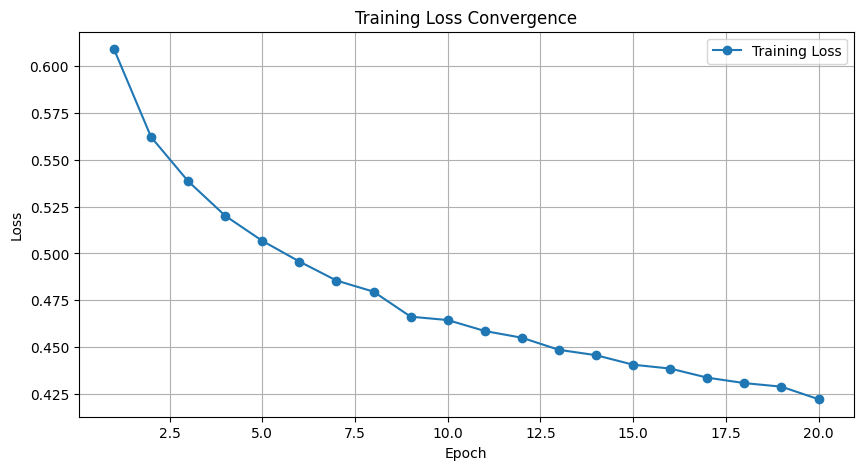

In [55]:
import time
import torch.optim as optim
import matplotlib.pyplot as plt

# Loss configuration (ignores <PAD> tokens)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# Sweet-spot optimizer configurations for scratch transformers
optimizer = optim.Adam(model.parameters(), lr=0.0003, betas=(0.9, 0.98), eps=1e-9)

epochs = 20

start_time = time.time()
epoch_losses = []

for epoch in range(1, epochs + 1):
    epoch_start = time.time()

    # Execute the parallel batch loader loop
    loss = train_epoch_parallel(model, train_loader, optimizer, criterion, device)
    epoch_losses.append(loss)

    epoch_duration = time.time() - epoch_start

    # Calculate perplexity (e^loss) to track model confidence
    perplexity = math.exp(loss) if loss < 20 else float('inf')

    print(f"Epoch [{epoch}/{epochs}] "
          f"| Loss: {loss:.4f} "
          f"| Perplexity: {perplexity:.2f} "
          f"| Time: {epoch_duration:.2f}s")

total_time = time.time() - start_time
print(f"\n Training Complete! Total time elapsed: {total_time/60:.2f} minutes")

# Requirement 5.1: Loss Tracking Analysis
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', label='Training Loss')
plt.title('Training Loss Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
def translate_sentence(model, sentence, input_lang, output_lang, device, max_len=10):
    model.eval()  # Set model to evaluation mode

    # 1. Preprocess and tokenize the incoming Amharic sentence
    normalized = normalize_amharic(sentence)
    src_indices = pad_sequence(sentence_to_indices(input_lang, normalized), max_len)

    # Convert to tensor and add batch dimension: [1, Max_Len]
    src_tensor = torch.tensor([src_indices], dtype=torch.long).to(device)
    src_mask = make_src_mask(src_tensor)

    # 2. Initialize the target sequence with just the starting <SOS> token
    tgt_indices = [SOS_TOKEN]

    # 3. Autoregressive generation loop
    for i in range(max_len):
        # Build the current running target tensor: [1, Current_Seq_Len]
        tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long).to(device)
        tgt_mask = make_tgt_mask(tgt_tensor)

        with torch.no_grad():
            # Pass the full state directly into your TransformerBlock forward method
            # logits shape: [1, Current_Seq_Len, Tgt_Vocab_Size]
            logits, cross_attn_weights = model(src_tensor, tgt_tensor, src_mask, tgt_mask)

            # Grab the logits at the very last predicted position index
            next_token_logits = logits[0, -1, :]
            next_token = torch.argmax(next_token_logits).item()

        # Stop decoding if the model generates the trailing <EOS> token
        if next_token == EOS_TOKEN:
            break

        tgt_indices.append(next_token)

    # 4. Convert the generated index values back into English strings
    translated_words = [output_lang.index2word.get(idx, "<UNK>") for idx in tgt_indices[1:]]
    return " ".join(translated_words), cross_attn_weights

In [57]:
import random

print("--- Section 5.2: Inference Evaluation Output ---")
# Ensure we sample 5 random pairs as per the assignment
sample_pairs = random.sample(pairs, 5)

for i, test_pair in enumerate(sample_pairs):
    amharic_input = test_pair[0]
    true_english = test_pair[1]

    prediction, attn_weights = translate_sentence(model, amharic_input, input_lang, output_lang, device)

    print(f"\nSample {i+1}:")
    print(f" Source Sentence (Amharic):  '{amharic_input}'")
    print(f" Ground Truth (English):    '{true_english}'")
    print(f" Model Output Prediction:   '{prediction}'")

sentence = sample_pairs[0][0]

prediction, attn_weights = translate_sentence(model, sentence, input_lang, output_lang, device)
print(f" Source Sentence (Amharic):  '{sentence}'")
print(f" Ground Truth (English):    '{true_english}'")
print(f" Model Output Prediction:   '{prediction}'")

--- Section 5.2: Inference Evaluation Output ---

Sample 1:
 Source Sentence (Amharic):  'ፈልግ'
 Ground Truth (English):    'search'
 Model Output Prediction:   'find'

Sample 2:
 Source Sentence (Amharic):  'ኢሜያል አድራሻ'
 Ground Truth (English):    'mailing list'
 Model Output Prediction:   'mailing list actions'

Sample 3:
 Source Sentence (Amharic):  'በሰሙድም ለእነርሱ እስከ ጊዜ ሞታችሁ ድረስ ተጣቀሙ በተባሉ ጊዜ ምልክት አልለ ፡ ፡'
 Ground Truth (English):    'and in thamud s also was a lesson when it was said unto them enjoy yourselves for a season .'
 Model Output Prediction:   'and for them are the time in thamud when it'

Sample 4:
 Source Sentence (Amharic):  'ሚስጢራዊ ቃል ፦'
 Ground Truth (English):    'password'
 Model Output Prediction:   'password'

Sample 5:
 Source Sentence (Amharic):  'የአማላጆችም ምልጃ አትጠቅማቸውም ፡ ፡'
 Ground Truth (English):    'then there will not profit them intercision of the interceders'
 Model Output Prediction:   'so there will not benefit them the intercession of any'
 Source Sentence (

In [58]:
# Install Ethiopic-capable font so Amharic glyphs render in the attention heatmap
# (matplotlib defaults often show Amharic characters as empty boxes otherwise)
!apt-get -qq install -y fonts-noto-core fonts-noto-extra

import matplotlib.font_manager as fm

# Rebuild matplotlib's font cache so it picks up the newly installed font
fm._load_fontmanager(try_read_cache=False)

ETHIOPIC_FONT = 'Noto Sans Ethiopic'
available_fonts = {f.name for f in fm.fontManager.ttflist}
if ETHIOPIC_FONT not in available_fonts:
    print(f"Warning: '{ETHIOPIC_FONT}' not found, falling back to 'Noto Sans'")
    ETHIOPIC_FONT = 'Noto Sans' if 'Noto Sans' in available_fonts else None
else:
    print(f"Using font: {ETHIOPIC_FONT}")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4936 (\N{ETHIOPIC SYLLABLE FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4621 (\N{ETHIOPIC SYLLABLE LE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4877 (\N{ETHIOPIC SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


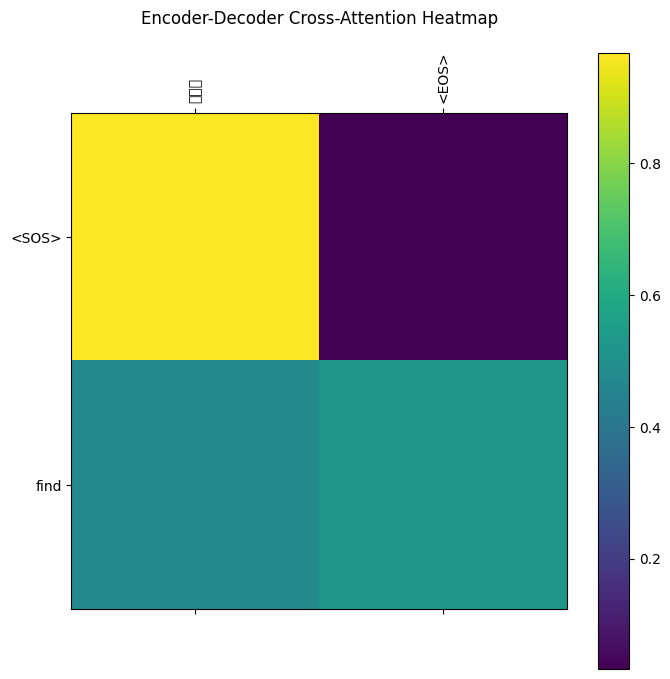

In [59]:
import matplotlib.ticker as ticker
import numpy as np

# Requirement 5.3: Attention Heatmap Visualization
def display_attention(sentence, translation, attention):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)

    # Extract the cross-attention matrix from the final decoder layer output
    # attention shape here natively: [Batch, Tgt_Len, Src_Len]
    attention_matrix = attention[0].cpu().detach().numpy()

    # Define labels EXACTLY matching the tensor token sequences
    x_labels = sentence.split(' ') + ['<EOS>']
    y_labels = ['<SOS>'] + translation.split(' ')

    # Crop the attention matrix to cut out the <PAD> tokens on the x-axis mapping
    attention_matrix = attention_matrix[:, :len(x_labels)]

    cax = ax.matshow(attention_matrix, cmap='viridis')
    fig.colorbar(cax)

    # Explicitly set ticks to fix the Matplotlib UserWarning
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))

    # Set up axes matching the tokens length without shifting
    # x_labels are Amharic (source side), so render them with the Ethiopic-capable
    # font installed above; y_labels are English and render fine with the default font.
    ax.set_xticklabels(x_labels, rotation=90, fontfamily=ETHIOPIC_FONT)
    ax.set_yticklabels(y_labels)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title('Encoder-Decoder Cross-Attention Heatmap', pad=20)
    plt.show()

# Visualize the attention map from the very last generated example above
display_attention(sentence, prediction, attn_weights)

In [60]:
import os

# --- Modular Checkpointing Subsystem ---
# This is crucial for pipeline reproducibility.

def save_checkpoint(model, input_lang, output_lang, config, filepath):
    """Saves the pipeline state into a portable binary payload."""
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'input_lang_words': input_lang.word2index,
        'input_lang_idx': input_lang.index2word,
        'input_lang_n': input_lang.n_words,
        'output_lang_words': output_lang.word2index,
        'output_lang_idx': output_lang.index2word,
        'output_lang_n': output_lang.n_words,
        'config': config
    }
    torch.save(checkpoint, filepath)
    print(f"Checkpoint successfully saved to {filepath}")



# Package the hyperparameters into a single config dictionary to ensure everything aligns!
model_config = {
    'd_model': D_MODEL,
    'n_heads': N_HEADS,
    'd_ff': D_FF,
    'n_layers': N_LAYERS,
    'max_len': MAX_LENGTH,
    'dropout': DROPOUT
}

# Example usage to guarantee your AM->EN work is saved:
save_checkpoint(model, input_lang, output_lang, model_config, checkpoint_path)

Checkpoint successfully saved to transformer_amen_v1.pth
